crim: per capita crime rate by town.

zn: proportion of residential land zoned for lots over 25,000 sq.ft.

indus: proportion of non-retail business acres per town.

chas: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).

nox: nitrogen oxides concentration (parts per 10 million).

rm: average number of rooms per dwelling.

age: proportion of owner-occupied units built prior to 1940.

dis: weighted mean of distances to five Boston employment centres.

rad: index of accessibility to radial highways.

tax: full-value property-tax rate per $10,000.

ptratio: pupil-teacher ratio by town.

lstat: lower status of the population (percent).

medv: median value of owner-occupied homes in $1000s.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
from ISLP import load_data

# Import auto dataset
boston = load_data("Boston")
boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

For each predictor, fit a simple linear regression model to predict
the response. Describe your results. In which of the models is
there a statistically significant association between the predictor
and the response? Create some plots to back up your assertions.

In [18]:
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS, summarize, poly)

target = "crim"
y = boston[target]

cols = [col for col in boston.columns if col != target]

models = []
results = []

for col in cols:
    X = MS([col]).fit_transform(boston)

    model = sm.OLS(y,X)
    models.append(model)

    result = model.fit()
    results.append(result)

    print(f"============= {col} ==============")
    print(summarize(result))
    print(result.rsquared_adj)

# Print significant predictors
alpha = 0.05
p_factors = [summarize(res)["P>|t|"].iloc[-1] for res in results]

sorted_indices = np.argsort(p_factors)

for i in sorted_indices:
    print(f"Col: {cols[i]}, p: {p_factors[i]}")


============= zn ==============
             coef  std err       t  P>|t|
intercept  4.4537    0.417  10.675    0.0
zn        -0.0739    0.016  -4.594    0.0
0.038283518960746
============= indus ==============
             coef  std err      t  P>|t|
intercept -2.0637    0.667 -3.093  0.002
indus      0.5098    0.051  9.991  0.000
0.16365393961811425
============= chas ==============
             coef  std err      t  P>|t|
intercept  3.7444    0.396  9.453  0.000
chas      -1.8928    1.506 -1.257  0.209
0.0011459401318837381
============= nox ==============
              coef  std err       t  P>|t|
intercept -13.7199    1.699  -8.073    0.0
nox        31.2485    2.999  10.419    0.0
0.17558467620101248
============= rm ==============
              coef  std err      t  P>|t|
intercept  20.4818    3.364  6.088    0.0
rm         -2.6841    0.532 -5.045    0.0
0.04618036496353595
============= age ==============
             coef  std err      t  P>|t|
intercept -3.7779    0.944 -4.002

/tmp/ipykernel_77443/3728172976.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'p = {res.pvalues[1]:.4f}, R² = {res.rsquared:.3f}')


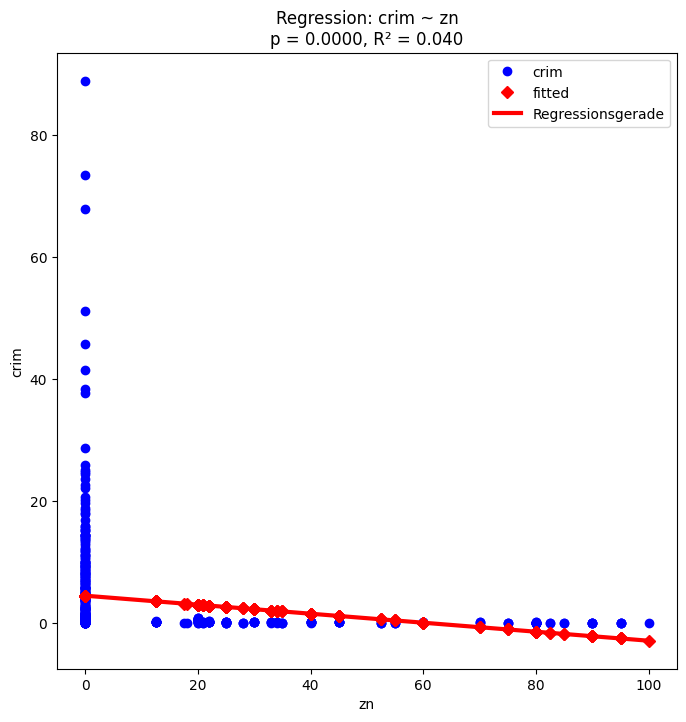

/tmp/ipykernel_77443/3728172976.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'p = {res.pvalues[1]:.4f}, R² = {res.rsquared:.3f}')


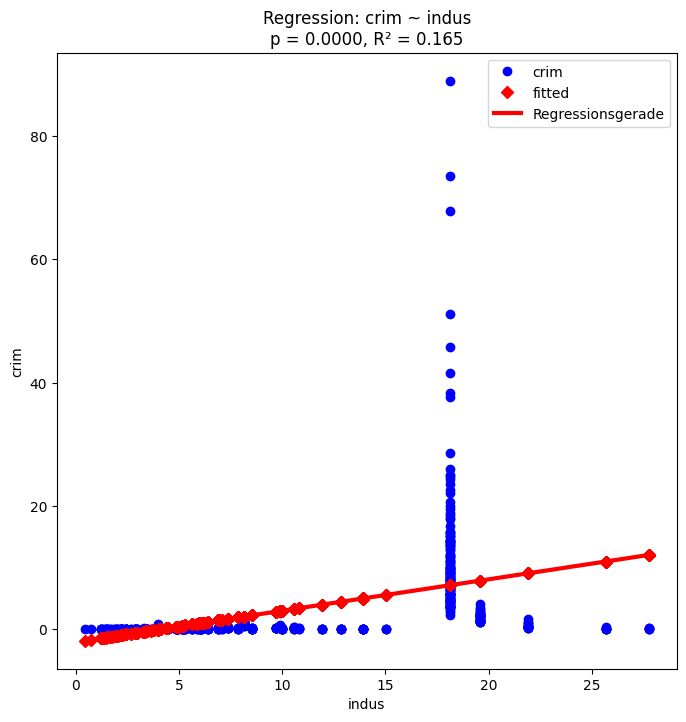

/tmp/ipykernel_77443/3728172976.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'p = {res.pvalues[1]:.4f}, R² = {res.rsquared:.3f}')


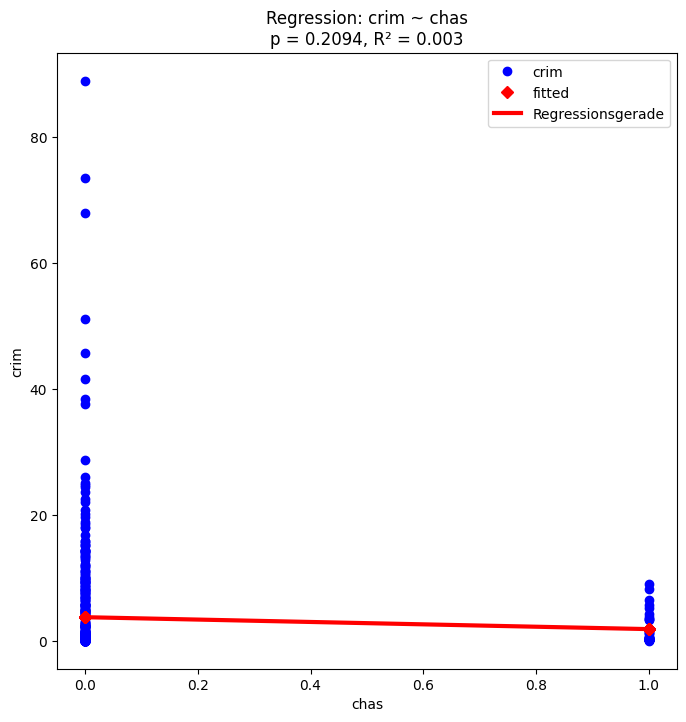

/tmp/ipykernel_77443/3728172976.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'p = {res.pvalues[1]:.4f}, R² = {res.rsquared:.3f}')


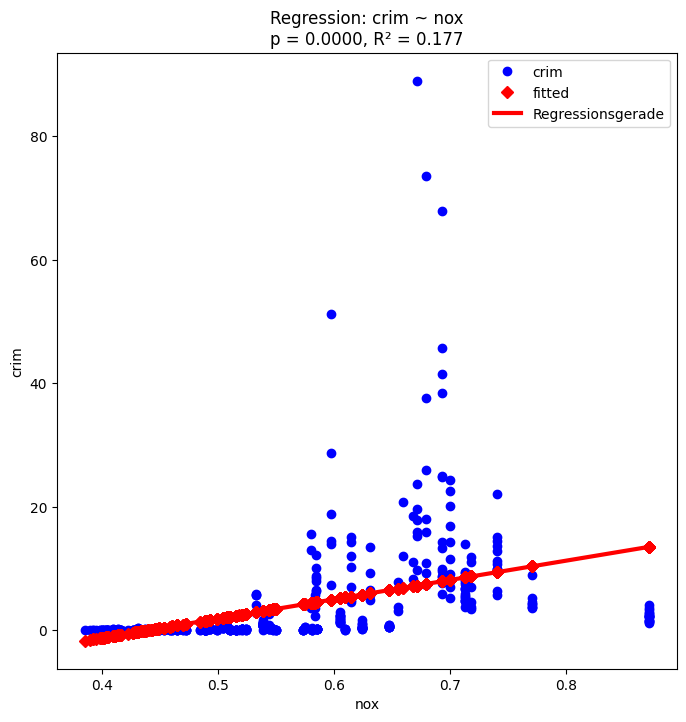

/tmp/ipykernel_77443/3728172976.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'p = {res.pvalues[1]:.4f}, R² = {res.rsquared:.3f}')


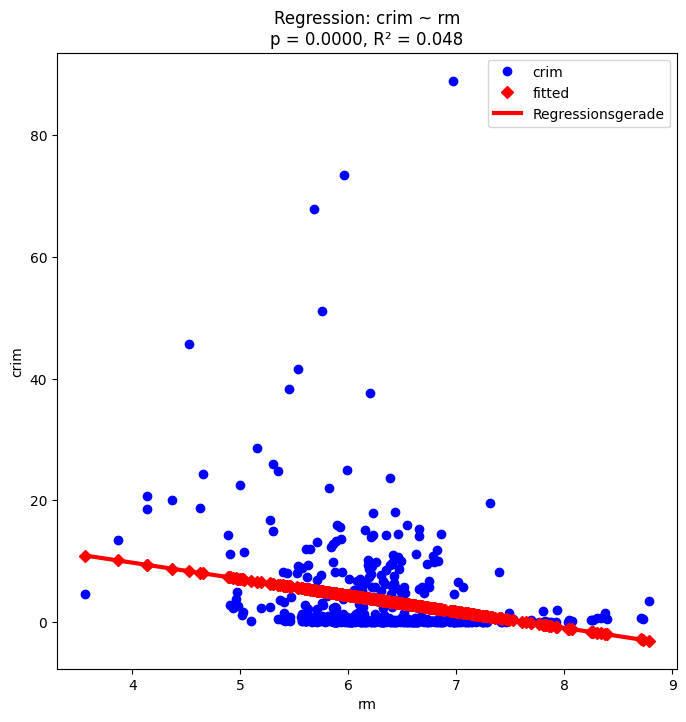

/tmp/ipykernel_77443/3728172976.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'p = {res.pvalues[1]:.4f}, R² = {res.rsquared:.3f}')


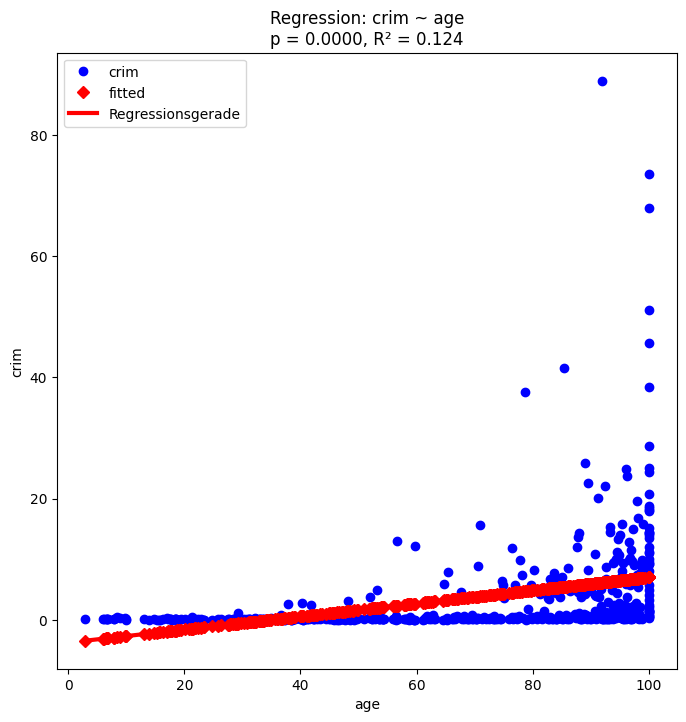

/tmp/ipykernel_77443/3728172976.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'p = {res.pvalues[1]:.4f}, R² = {res.rsquared:.3f}')


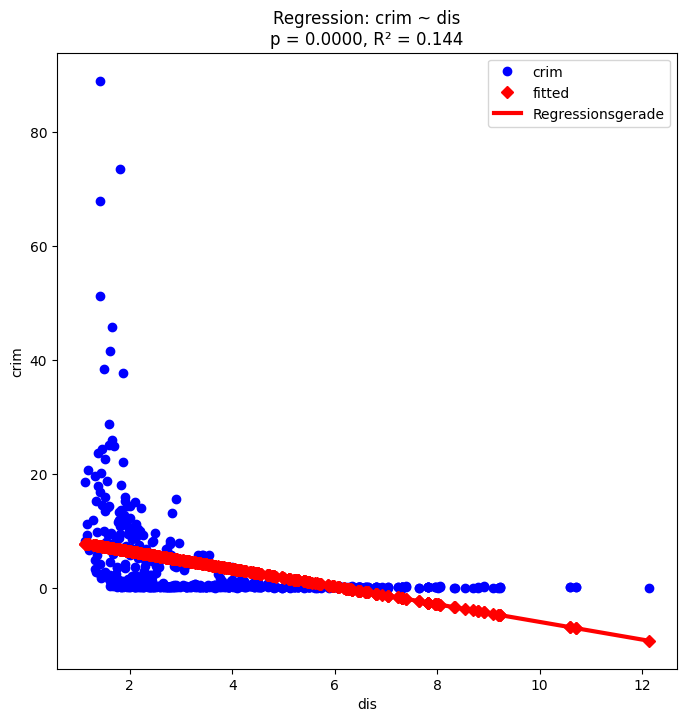

/tmp/ipykernel_77443/3728172976.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'p = {res.pvalues[1]:.4f}, R² = {res.rsquared:.3f}')


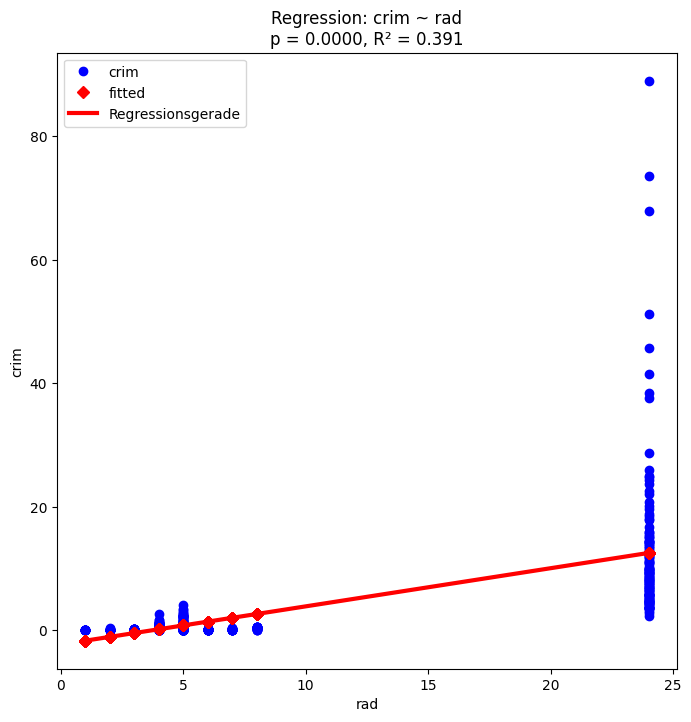

/tmp/ipykernel_77443/3728172976.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'p = {res.pvalues[1]:.4f}, R² = {res.rsquared:.3f}')


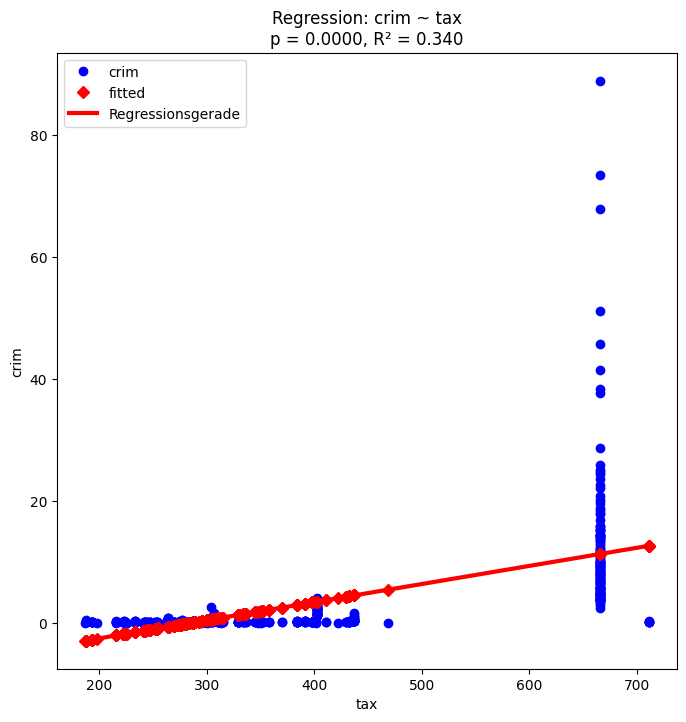

/tmp/ipykernel_77443/3728172976.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'p = {res.pvalues[1]:.4f}, R² = {res.rsquared:.3f}')


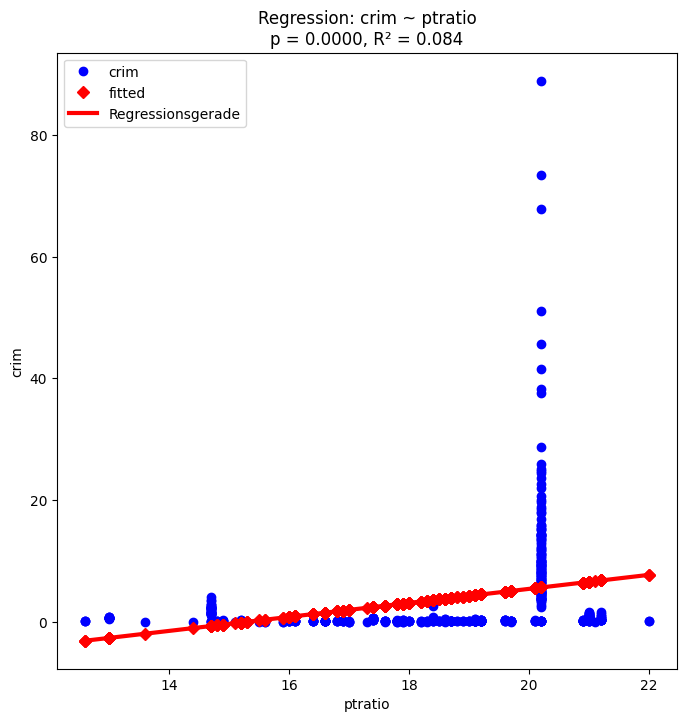

/tmp/ipykernel_77443/3728172976.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'p = {res.pvalues[1]:.4f}, R² = {res.rsquared:.3f}')


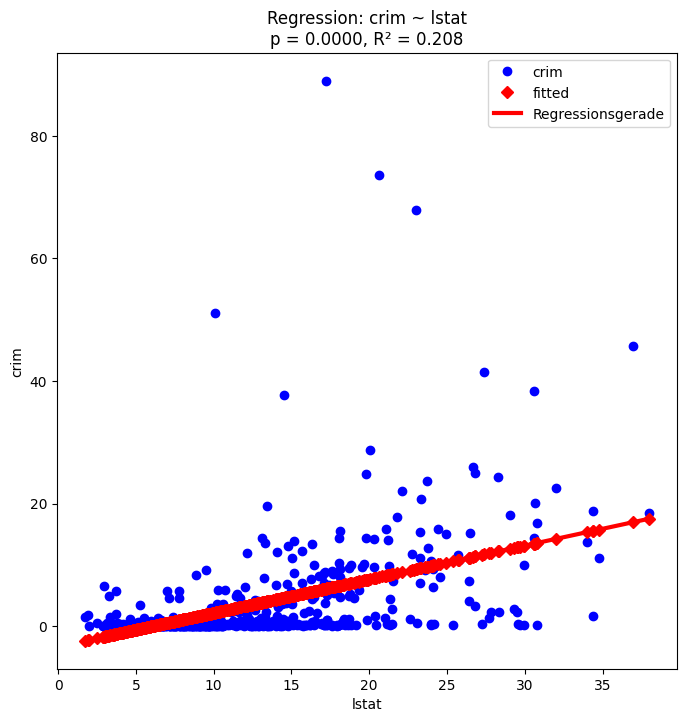

/tmp/ipykernel_77443/3728172976.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'p = {res.pvalues[1]:.4f}, R² = {res.rsquared:.3f}')


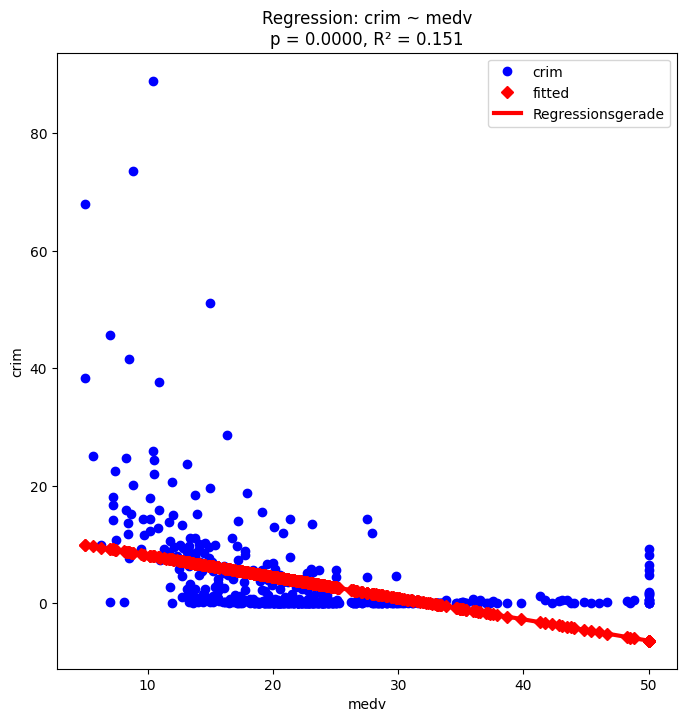

In [29]:
# Plotting regressions

for i,col in enumerate(cols):
    res = results[i]

    fig, ax = plt.subplots(figsize=(8,8))
    sm.graphics.plot_fit(res, 1, ax=ax, vlines=False)  # 1 = Index des Predictors
    ax.set_title(f'Fit Plot für {cols[i]}')

    x_data = boston[col]
    x_range = np.linspace(x_data.min(), x_data.max(), 100)
    
    X_pred = MS([col]).fit_transform(pd.DataFrame({col: x_range}))
    y_pred = res.predict(X_pred)
    
    ax.plot(x_range, y_pred, 'r-', linewidth=3, label='Regressionsgerade')
    
    ax.set_title(f'Regression: crim ~ {col}\n'
                 f'p = {res.pvalues[1]:.4f}, R² = {res.rsquared:.3f}')
    ax.legend()
    plt.show()

medv, lstat, dis, age, (nox) seem to have a statistical association with the target variable.

In [32]:
X = MS(cols).fit_transform(boston)

model_all = sm.OLS(y,X)
result_all = model_all.fit()
print(summarize(result_all))
print(result_all.rsquared_adj)

              coef  std err      t  P>|t|
intercept  13.7784    7.082  1.946  0.052
zn          0.0457    0.019  2.433  0.015
indus      -0.0584    0.084 -0.698  0.486
chas       -0.8254    1.183 -0.697  0.486
nox        -9.9576    5.290 -1.882  0.060
rm          0.6289    0.607  1.036  0.301
age        -0.0008    0.018 -0.047  0.962
dis        -1.0122    0.282 -3.584  0.000
rad         0.6125    0.088  6.997  0.000
tax        -0.0038    0.005 -0.730  0.466
ptratio    -0.3041    0.186 -1.632  0.103
lstat       0.1388    0.076  1.833  0.067
medv       -0.2201    0.060 -3.678  0.000
0.4359342692317244


Adj. R² score is 0.4356.., which isn't great but a start. Based on the P>|t| score, the following predictors seem to be significant:

zn, dis, rad, medv -> significant

nox, ptratio, lstat -> borderline

 How do your results from (a) compare to your results from (b)?
Create a plot displaying the univariate regression coefficients
from (a) on the x-axis, and the multiple regression coefficients
from (b) on the y-axis. That is, each predictor is displayed as a
single point in the plot. Its coefficient in a simple linear regres-
sion model is shown on the x-axis, and its coefficient estimate
in the multiple linear regression model is shown on the y-axis.

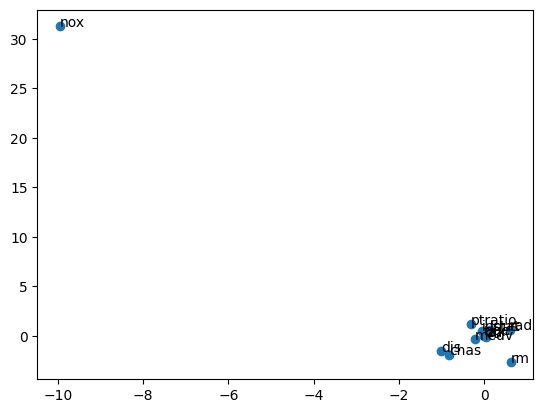

In [44]:
# coefs = [(summarize(result_all)["coef"][col], summarize(results[i])["coef"][col]) for i, col in enumerate(cols)]
single_coefs = []
multiple_coefs = []
for i, col in enumerate(cols):
    single_coefs.append(summarize(result_all)["coef"][col])
    multiple_coefs.append(summarize(results[i])["coef"][col])
    plt.annotate(col, (single_coefs[-1], multiple_coefs[-1]))

plt.scatter(single_coefs, multiple_coefs)

Most coefficients are relatively similar to each other (pretty much 0). Dis, chas, ptratio differ a bit, but by far the most discernible difference is nox, which seemed to be -10 in the linear regression and became over +30 in the multiple, so a pretty noticable difference.

In [ ]:
models = []
results = []
non_linear_evidence = []

for col in cols:
    X = MS([poly(col, degree=3)]).fit_transform(boston)

    model = sm.OLS(y,X)
    models.append(model)

    result = model.fit()
    results.append(result)

    print(summarize(result))
    print(result.rsquared_adj)

    p_values = result.pvalues
    higher_terms_significant = any(p_values[2:] < 0.05)  # Quadratische und kubische Terme
    
    if higher_terms_significant:
        non_linear_evidence.append(col)


for ev in non_linear_evidence:
    print(ev)

                          coef  std err      t  P>|t|
intercept               3.6135    0.372  9.709  0.000
poly(zn, degree=3)[0] -38.7498    8.372 -4.628  0.000
poly(zn, degree=3)[1]  23.9398    8.372  2.859  0.004
poly(zn, degree=3)[2] -10.0719    8.372 -1.203  0.230
0.052613938211961475
                             coef  std err       t  P>|t|
intercept                  3.6135    0.330  10.950  0.000
poly(indus, degree=3)[0]  78.5908    7.423  10.587  0.000
poly(indus, degree=3)[1] -24.3948    7.423  -3.286  0.001
poly(indus, degree=3)[2] -54.1298    7.423  -7.292  0.000
0.25523350248880683
                           coef  std err      t  P>|t|
intercept                3.6927    0.388  9.505  0.000
poly(chas, degree=3)[0] -0.1178    0.066 -1.784  0.075
poly(chas, degree=3)[1] -0.5757    0.234 -2.460  0.014
poly(chas, degree=3)[2] -0.7966    0.708 -1.125  0.261
0.0011459401318837381
                           coef  std err       t  P>|t|
intercept                3.6135    0.322  11.2

Yes there is evidence, as a lot of higher degree terms have a low p-value, hinting at a non-linear association between the predictor and the target variable